# Importing Dependencies and Environment Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded ✓")

Libraries loaded ✓


In [3]:
#loading the dataset
ex = pd.read_csv('G2-TCGA-HNSC_EX.csv', header=0)
X = ex.iloc[:,1:] #dropping the first column

#loading the labels
y = pd.read_csv('G2-TCGA-HNSC_Label.csv', header=0)
y = y.iloc[:,0] #convert to a series or a single vector

print(f"Gene expression matrix: {X.shape}")
print(f"Labels: {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts().rename({0:'Healthy', 1:'Cancerous'}))

Gene expression matrix: (563, 35957)
Labels: (563,)

Class distribution:
0
Cancerous    520
Healthy       43
Name: count, dtype: int64


Dataset is inbalanced

# EDA

In [4]:
print("=" * 55)
print("DATASET: TCGA-HNSC Gene Expression (Head & Neck Cancer)")
print("=" * 55)
print(f"\nSamples (patients):     {X.shape[0]}")
print(f"Features (genes):       {X.shape[1]}")
print(f"Missing values:         {X.isnull().sum().sum()}")
print(f"Data type:              {X.dtypes.unique()[0]} (RNA-seq read counts)")

print(f"\nClass Distribution:")
counts = y.value_counts().rename({0: 'Healthy (0)', 1: 'Cancerous (1)'})
for label, count in counts.items():
    pct = count / len(y) * 100
    print(f"  {label}: {count} samples ({pct:.1f}%)")

DATASET: TCGA-HNSC Gene Expression (Head & Neck Cancer)

Samples (patients):     563
Features (genes):       35957
Missing values:         0
Data type:              int64 (RNA-seq read counts)

Class Distribution:
  Cancerous (1): 520 samples (92.4%)
  Healthy (0): 43 samples (7.6%)


Severe class imbalance (92% / 8%)

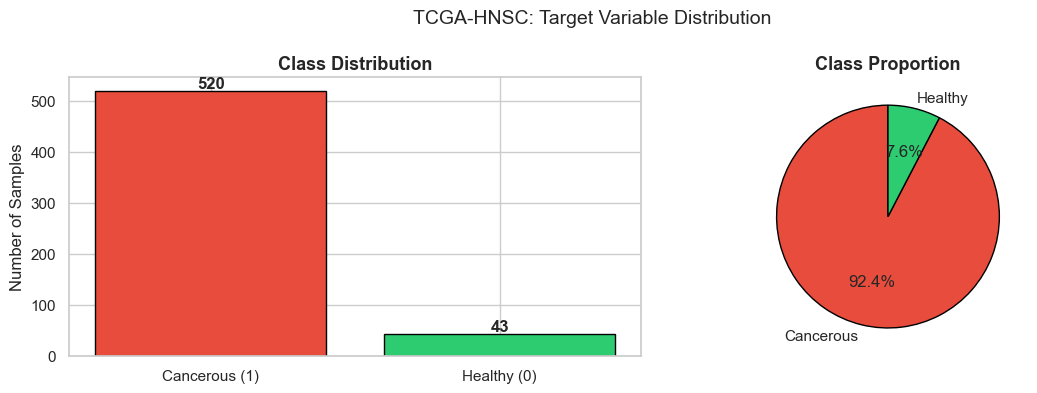

In [11]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

#Bar Chart
counts = y.value_counts() #to get the count of healthy(0) vs cancerous(1)
axes[0].bar(['Cancerous (1)', 'Healthy (0)'],
            [counts[1], counts[0]],
            color = ["#e74c3c", "#2ecc71"], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')

for i, v in enumerate([counts[1], counts[0]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie Chart
axes[1].pie([counts[1], counts[0]],
            labels=['Cancerous', 'Healthy'],
            colors=['#e74c3c', '#2ecc71'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('TCGA-HNSC: Target Variable Distribution', fontsize=14)
plt.tight_layout()
plt.show()



Again we see high class inbalance. If we make a model that predicts cancerous always it will have a 92% accuracy, therefore we need to opt for other metrics like F1 score.

In [ ]:
stats = X.describe().T  # gets the stats for each column and transpose so genes are rows

print("Summary Statistics (per gene across all samples):")
print(f"  Mean expression range:   {stats['mean'].min():.1f}  -  {stats['mean'].max():.1f}")
print(f"  Std dev range:           {stats['std'].min():.1f}  -  {stats['std'].max():.1f}")
print(f"  Min value:               {stats['min'].min():.0f}")
print(f"  Max value:               {stats['max'].max():.0f}")
print(f"\nGenes with zero mean (never expressed): {(stats['mean'] == 0).sum()}")
print(f"Genes with very low variance (std < 1):  {(stats['std'] < 1).sum()}")

Summary Statistics (per gene across all samples):
  Mean expression range:   0.0  -  7199.8
  Std dev range:           0.2  -  2391.3
  Min value:               0
  Max value:               20376

Genes with zero mean (never expressed): 0
Genes with very low variance (std < 1):  7381


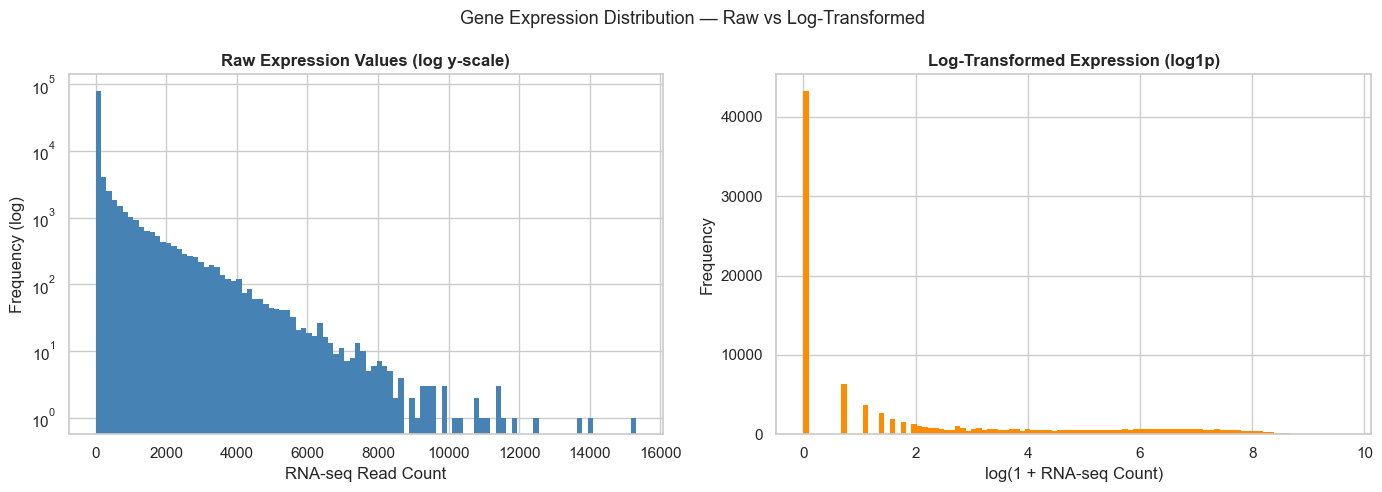

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts — sample 1000 random gene values for speed
sample_vals = X.values.flatten()
np.random.seed(42)
sample_vals = np.random.choice(sample_vals, size=100000, replace=False)

axes[0].hist(sample_vals, bins=100, color='steelblue',
             edgecolor='none', log=True)
axes[0].set_title('Raw Expression Values (log y-scale)', fontweight='bold')
axes[0].set_xlabel('RNA-seq Read Count')
axes[0].set_ylabel('Frequency (log)')

# Log-transformed
log_vals = np.log1p(sample_vals)   # log1p = log(1+x), handles zeros
axes[1].hist(log_vals, bins=100, color='darkorange', edgecolor='none')
axes[1].set_title('Log-Transformed Expression (log1p)', fontweight='bold')
axes[1].set_xlabel('log(1 + RNA-seq Count)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Gene Expression Distribution — Raw vs Log-Transformed',
             fontsize=13)
plt.tight_layout()
plt.show()

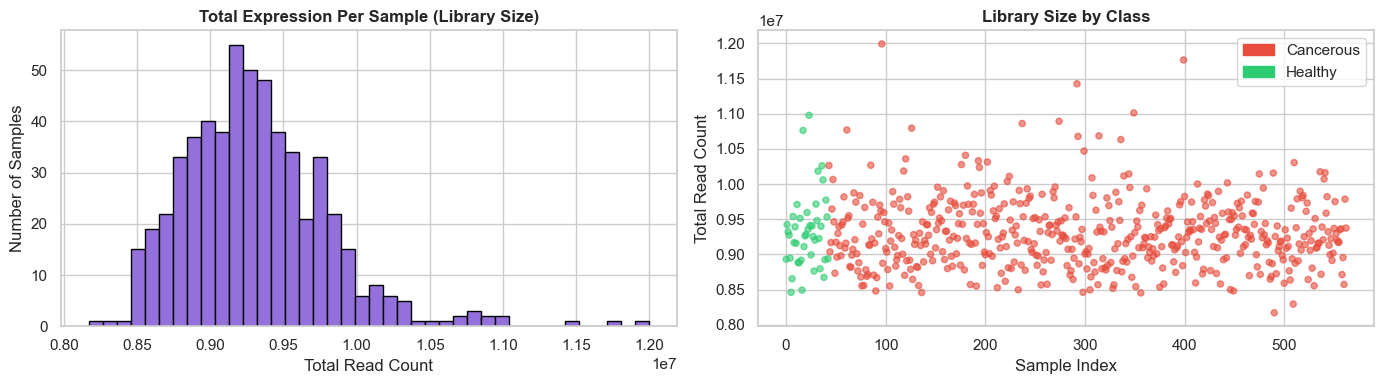

Mean library size:   9,306,869
Std library size:    497,064
Min library size:    8,170,379
Max library size:    11,994,100


In [15]:
sample_totals = X.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sample_totals, bins=40, color='mediumpurple', edgecolor='black')
axes[0].set_title('Total Expression Per Sample (Library Size)', fontweight='bold')
axes[0].set_xlabel('Total Read Count')
axes[0].set_ylabel('Number of Samples')

# Colored by class
colors = y.map({0: '#2ecc71', 1: '#e74c3c'})
axes[1].scatter(range(len(sample_totals)), sample_totals,
                c=colors, alpha=0.6, s=20)
axes[1].set_title('Library Size by Class', fontweight='bold')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Total Read Count')

from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='Cancerous'),
          Patch(color='#2ecc71', label='Healthy')]
axes[1].legend(handles=legend)

plt.tight_layout()
plt.show()

print(f"Mean library size:   {sample_totals.mean():,.0f}")
print(f"Std library size:    {sample_totals.std():,.0f}")
print(f"Min library size:    {sample_totals.min():,.0f}")
print(f"Max library size:    {sample_totals.max():,.0f}")

## EDA Summary & Key Observations

| Observation | Implication for Modeling |
|-------------|--------------------------|
| 563 samples, 35,957 genes | Far more features than samples meaning feature selection is mandatory |
| 92% Cancerous / 8% Healthy | Severe class imbalance therefore use F1-score and ROC-AUC, not accuracy |
| Raw counts heavily right-skewed | Need to apply log1p transformation before training |
| Many genes with zero/near-zero expression | Remove low-variance genes to reduce dimensionality |
| Library sizes consistent across classes | No sequencing depth bias therefore no per-sample normalization needed |

# Preprocessing